In [302]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.python.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
import sklearn
from sklearn.metrics import confusion_matrix, classification_report

In [212]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [262]:
train = tf.keras.utils.image_dataset_from_directory(directory="./data/train", validation_split=0.2, subset='training', batch_size=32, seed=42,shuffle=True, label_mode="categorical", image_size=(224,224), interpolation="nearest" )

Found 6957 files belonging to 2 classes.
Using 5566 files for training.


In [263]:
val = tf.keras.utils.image_dataset_from_directory(directory="./data/train", validation_split=0.2, subset='validation', batch_size=32, seed=42, shuffle=True, label_mode="categorical", image_size=(224,224), interpolation="nearest" )

Found 6957 files belonging to 2 classes.
Using 1391 files for validation.


In [306]:
test = tf.keras.utils.image_dataset_from_directory(directory="./data/test", batch_size=32, shuffle=False, label_mode="categorical", image_size=(224,224), interpolation="nearest" )

Found 1573 files belonging to 2 classes.


In [265]:
train

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

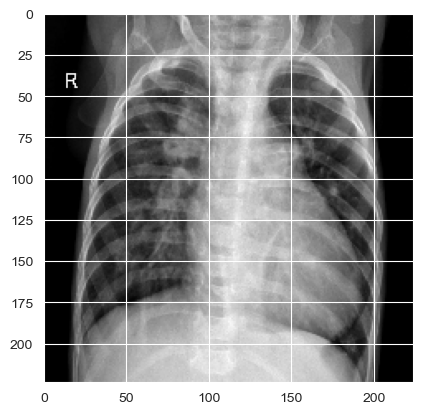

In [266]:
for images, labels in train.take(1):
    plt.imshow(images[0].numpy().reshape(224,224,3))

In [267]:
data_segmentation = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [268]:
EfficientNet_model = tf.keras.applications.efficientnet.EfficientNetB0(weights='imagenet', input_shape=(224,224,3), pooling="max", include_top=False)

In [269]:
EfficientNet_model.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_21 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_22 (Rescaling)       (None, 224, 224, 3)  0           ['input_21[0][0]']               
                                                                                                  
 normalization_11 (Normalizatio  (None, 224, 224, 3)  7          ['rescaling_22[0][0]']           
 n)                                                                                               
                                                                                     

In [270]:
EfficientNet_model.trainable = False

In [273]:

x = EfficientNet_model.output
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
model = tf.keras.Model(EfficientNet_model.input, outputs)

In [274]:
model.summary()

Model: "model_17"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_21 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_22 (Rescaling)       (None, 224, 224, 3)  0           ['input_21[0][0]']               
                                                                                                  
 normalization_11 (Normalizatio  (None, 224, 224, 3)  7          ['rescaling_22[0][0]']           
 n)                                                                                               
                                                                                           

In [275]:
train = train.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val = val.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

In [307]:
test = test.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

In [277]:
efficient_EarlyStop = EarlyStopping(monitor='val_accuracy', patience=7, verbose=2, mode='max', restore_best_weights=True)
efficient_ReduceLROnPlateau = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=4, mode='max',)

In [278]:
model.compile(optimizer=Adam(learning_rate=0.001), loss=categorical_crossentropy, metrics=['accuracy'])

In [279]:
history = model.fit(test, validation_data=val, epochs=50, verbose=2, callbacks=[efficient_EarlyStop, efficient_ReduceLROnPlateau])

Epoch 1/50
50/50 - 11s - loss: 1.5253 - accuracy: 0.6567 - val_loss: 0.2757 - val_accuracy: 0.8950 - lr: 0.0010 - 11s/epoch - 227ms/step
Epoch 2/50
50/50 - 7s - loss: 0.3866 - accuracy: 0.8398 - val_loss: 0.2353 - val_accuracy: 0.8965 - lr: 0.0010 - 7s/epoch - 136ms/step
Epoch 3/50
50/50 - 7s - loss: 0.3221 - accuracy: 0.8684 - val_loss: 0.2448 - val_accuracy: 0.8950 - lr: 0.0010 - 7s/epoch - 135ms/step
Epoch 4/50
50/50 - 7s - loss: 0.2866 - accuracy: 0.8843 - val_loss: 0.1986 - val_accuracy: 0.9224 - lr: 0.0010 - 7s/epoch - 136ms/step
Epoch 5/50
50/50 - 7s - loss: 0.2257 - accuracy: 0.9110 - val_loss: 0.1585 - val_accuracy: 0.9375 - lr: 0.0010 - 7s/epoch - 136ms/step
Epoch 6/50
50/50 - 7s - loss: 0.2372 - accuracy: 0.9046 - val_loss: 0.1740 - val_accuracy: 0.9346 - lr: 0.0010 - 7s/epoch - 136ms/step
Epoch 7/50
50/50 - 7s - loss: 0.2052 - accuracy: 0.9205 - val_loss: 0.1574 - val_accuracy: 0.9389 - lr: 0.0010 - 7s/epoch - 136ms/step
Epoch 8/50
50/50 - 7s - loss: 0.2102 - accuracy: 0.91

In [308]:
model.evaluate(test)

50/50 [==============================] - 4s 66ms/step - loss: 0.0716 - accuracy: 0.9746


[0.07162697613239288, 0.9745708703994751]

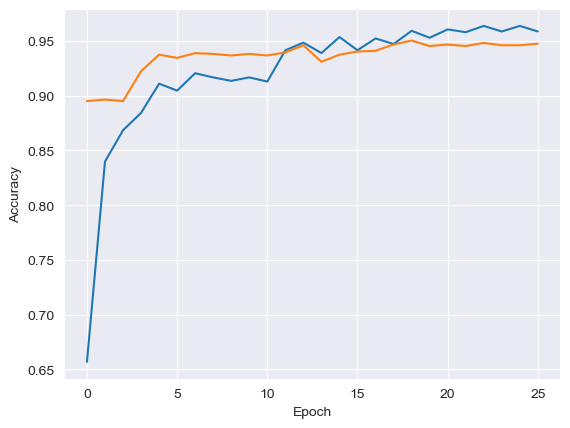

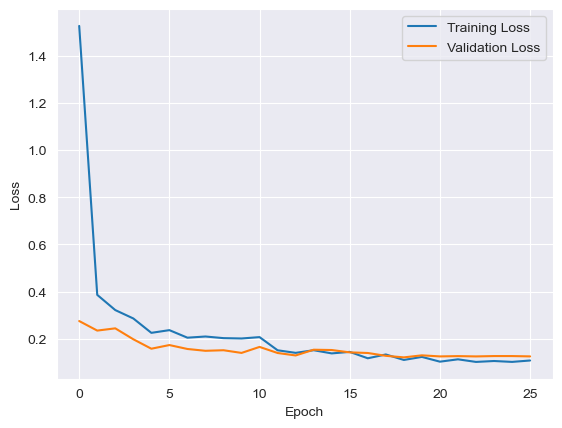

In [290]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [299]:
classes = ["Normal", "Pneumonia"]

50/50 [==============================] - 3s 69ms/step


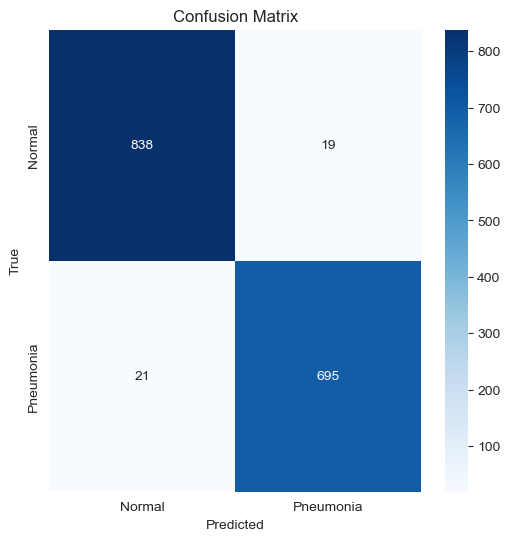

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       857
   Pneumonia       0.97      0.97      0.97       716

    accuracy                           0.97      1573
   macro avg       0.97      0.97      0.97      1573
weighted avg       0.97      0.97      0.97      1573



In [310]:
y_pred_probs = model.predict(test)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for _, labels in test:
    y_true.extend(tf.argmax(labels, axis=1).numpy())
y_true = np.array(y_true)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

In [311]:
model.save_weights('./models/chest_xray_model_weights.h5')